# Project Area 7: Graphs — Molecules

**Goal:** Predict whether a molecule can cross the blood-brain barrier (BBBP dataset) using a Graph Convolutional Network (GCN).

A molecule is naturally a graph: **atoms are dots (nodes)**, **bonds are lines (edges)**. We'll let a graph neural network learn to predict a yes/no property directly from this structure.

**What this notebook does, step by step:**
1. Install PyTorch Geometric
2. Load the BBBP dataset (built into PyTorch Geometric, one line of code)
3. Build a small GCN
4. Train it and evaluate (accuracy + AUC)
5. Compare it against a "silly baseline" (always guess the most common class)
6. Bonus: a stronger GIN model + a proper scaffold split (the "honest" way to test)
7. Understanding-check answers

Runs top-to-bottom ("Run All") on Kaggle's free GPU or even CPU — this dataset is tiny.

## 0. Setup

On Kaggle: **Settings → Accelerator → GPU**, and **Internet: On** (needed once, to download the dataset).

On Colab: **Runtime → Change runtime type → GPU**.

In [1]:
# Install PyTorch Geometric (PyG) and its dependencies.
# This usually takes 1-2 minutes.
import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

TORCH = torch.__version__.split('+')[0]
CUDA = 'cu121' if torch.cuda.is_available() else 'cpu'

!pip install -q torch_geometric
!pip install -q rdkit  # needed for the bonus scaffold split

Torch version: 2.11.0+cu128
CUDA available: True
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 63.7 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn.functional as F
from torch.nn import Linear

from torch_geometric.datasets import MoleculeNet
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, GINConv, global_mean_pool

from sklearn.metrics import roc_auc_score, accuracy_score
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


## 1. Load the data

`MoleculeNet` from PyTorch Geometric loads BBBP in one line — no manual download needed. Each molecule arrives already converted into a graph:
- **Nodes** = atoms (with features like atom type, charge, etc.)
- **Edges** = bonds
- **Label (y)** = whether the molecule can cross the blood-brain barrier (1 = yes, 0 = no)

In [3]:
dataset = MoleculeNet(root='data/BBBP', name='BBBP')

print(f"Number of molecules (graphs): {len(dataset)}")
print(f"Number of node features (atom features): {dataset.num_node_features}")
print(f"Number of classes: {dataset.num_classes}")

sample = dataset[0]
print("\nExample molecule (one graph):")
print(sample)
print("SMILES string:", sample.smiles)
print("Label (1 = crosses blood-brain barrier):", sample.y.item())

Processing...
/usr/local/lib/python3.12/dist-packages/torch_geometric/data/dataset.py:266: UserWarning: Skipping molecule 'O=N([O-])C1=C(CN=C1NCCSCc2ncccc2)Cc3ccccc3' since it resulted in zero atoms
  self.process()
/usr/local/lib/python3.12/dist-packages/torch_geometric/data/dataset.py:266: UserWarning: Skipping molecule 'c1(nc(NC(N)=[NH2])sc1)CSCCNC(=[NH]C#N)NC' since it resulted in zero atoms
  self.process()
/usr/local/lib/python3.12/dist-packages/torch_geometric/data/dataset.py:266: UserWarning: Skipping molecule 'Cc1nc(sc1)\[NH]=C(\N)N' since it resulted in zero atoms
  self.process()
/usr/local/lib/python3.12/dist-packages/torch_geometric/data/dataset.py:266: UserWarning: Skipping molecule 's1cc(CSCCN\C(NC)=[NH]\C#N)nc1\[NH]=C(\N)N' since it resulted in zero atoms
  self.process()
/usr/local/lib/python3.12/dist-packages/torch_geometric/data/dataset.py:266: UserWarning: Skipping molecule 'c1c(c(ncc1)CSCCN\C(=[NH]\C#N)NCC)Br' since it resulted in zero atoms
  self.process()
/usr/l

Number of molecules (graphs): 2039
Number of node features (atom features): 9
Number of classes: 2

Example molecule (one graph):
Data(x=[20, 9], edge_index=[2, 40], edge_attr=[40, 3], smiles='[Cl].CC(C)NCC(O)COc1cccc2ccccc12', y=[1, 1])
SMILES string: [Cl].CC(C)NCC(O)COc1cccc2ccccc12
Label (1 = crosses blood-brain barrier): 1.0


Done!


Some molecules in this dataset have isolated atoms or other quirks that break GCN. We do a quick clean pass and drop graphs with zero edges.

In [4]:
# Filter out any broken/disconnected graphs (no edges)
clean_list = [d for d in dataset if d.edge_index.numel() > 0]
print(f"Kept {len(clean_list)} / {len(dataset)} molecules after filtering empty-edge graphs")

Kept 2039 / 2039 molecules after filtering empty-edge graphs


## 2. Split the data (random split for the basic version)

We'll do a simple random 80/10/10 train/val/test split first. (Later, in the bonus section, we redo this with a *scaffold split* — the harder, more honest way molecules are usually tested.)

In [5]:
import random
random.seed(42)
shuffled = clean_list.copy()
random.shuffle(shuffled)

n = len(shuffled)
n_train = int(0.8 * n)
n_val = int(0.1 * n)

train_set = shuffled[:n_train]
val_set = shuffled[n_train:n_train + n_val]
test_set = shuffled[n_train + n_val:]

print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
val_loader = DataLoader(val_set, batch_size=64, shuffle=False)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

Train: 1631 | Val: 203 | Test: 205


## 3. The silly baseline

Before training any neural network, let's see what score you'd get by **always guessing the most common class**. Our GCN needs to beat this to prove it's actually learning something.

In [6]:
train_labels = [d.y.item() for d in train_set]
test_labels = [d.y.item() for d in test_set]

majority_class = max(set(train_labels), key=train_labels.count)
print(f"Most common class in training set: {majority_class}")

baseline_preds = [majority_class] * len(test_labels)
baseline_acc = accuracy_score(test_labels, baseline_preds)

# AUC needs probabilities; a constant prediction gives AUC = 0.5 (pure chance)
baseline_auc = 0.5

print(f"Baseline accuracy (always guess class {majority_class}): {baseline_acc:.3f}")
print(f"Baseline AUC (random guessing): {baseline_auc:.3f}")

Most common class in training set: 1.0
Baseline accuracy (always guess class 1.0): 0.761
Baseline AUC (random guessing): 0.500


## 4. Build the GCN

This is the "copy a small example graph network" step — a standard small GCN for graph classification:

1. A couple of `GCNConv` layers let each atom "look at" its neighboring atoms and update its own representation (this is the message-passing idea).
2. `global_mean_pool` squashes all the atom-level vectors in one molecule into a single graph-level vector (since we want one prediction per *molecule*, not per atom).
3. A final linear layer turns that vector into a yes/no prediction.

In [7]:
class GCN(torch.nn.Module):
    def __init__(self, num_node_features, hidden_channels=64):
        super().__init__()
        self.conv1 = GCNConv(num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, 1)  # binary classification -> 1 logit

    def forward(self, x, edge_index, batch):
        # 1. Message passing: each atom updates itself using its neighbors
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index).relu()
        x = self.conv3(x, edge_index)

        # 2. Pool: combine all atoms in a molecule into one graph-level vector
        x = global_mean_pool(x, batch)

        # 3. Classify
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.lin(x)
        return x

model = GCN(dataset.num_node_features).to(device)
print(model)

GCN(
  (conv1): GCNConv(9, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=1, bias=True)
)


## 5. Train it

In [8]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
criterion = torch.nn.BCEWithLogitsLoss()

def train_one_epoch():
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x.float(), data.edge_index, data.batch) # Removed .squeeze()
        loss = criterion(out, data.y.float())
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(train_loader.dataset)

@torch.no_grad()
def evaluate(loader):
    model.eval()
    all_probs, all_labels = [], []
    for data in loader:
        data = data.to(device)
        out = model(data.x.float(), data.edge_index, data.batch) # Removed .squeeze()
        probs = torch.sigmoid(out)
        all_probs.append(probs.cpu())
        all_labels.append(data.y.cpu())
    all_probs = torch.cat(all_probs).numpy()
    all_labels = torch.cat(all_labels).numpy()
    preds = (all_probs > 0.5).astype(int)
    acc = accuracy_score(all_labels, preds)
    auc = roc_auc_score(all_labels, all_probs)
    return acc, auc

In [9]:
EPOCHS = 60
train_losses = []
val_aucs = []

for epoch in range(1, EPOCHS + 1):
    loss = train_one_epoch()
    train_losses.append(loss)
    val_acc, val_auc = evaluate(val_loader)
    val_aucs.append(val_auc)
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | Train loss: {loss:.4f} | Val acc: {val_acc:.3f} | Val AUC: {val_auc:.3f}")

Epoch 001 | Train loss: 0.5870 | Val acc: 0.759 | Val AUC: 0.617
Epoch 005 | Train loss: 0.5236 | Val acc: 0.759 | Val AUC: 0.616
Epoch 010 | Train loss: 0.4865 | Val acc: 0.759 | Val AUC: 0.636
Epoch 015 | Train loss: 0.4607 | Val acc: 0.783 | Val AUC: 0.653
Epoch 020 | Train loss: 0.4569 | Val acc: 0.783 | Val AUC: 0.648
Epoch 025 | Train loss: 0.4527 | Val acc: 0.778 | Val AUC: 0.644
Epoch 030 | Train loss: 0.4440 | Val acc: 0.773 | Val AUC: 0.640
Epoch 035 | Train loss: 0.4506 | Val acc: 0.749 | Val AUC: 0.646
Epoch 040 | Train loss: 0.4486 | Val acc: 0.749 | Val AUC: 0.648
Epoch 045 | Train loss: 0.4337 | Val acc: 0.768 | Val AUC: 0.647
Epoch 050 | Train loss: 0.4369 | Val acc: 0.778 | Val AUC: 0.646
Epoch 055 | Train loss: 0.4280 | Val acc: 0.788 | Val AUC: 0.651
Epoch 060 | Train loss: 0.4277 | Val acc: 0.768 | Val AUC: 0.659


### Show the training progress (loss going down)

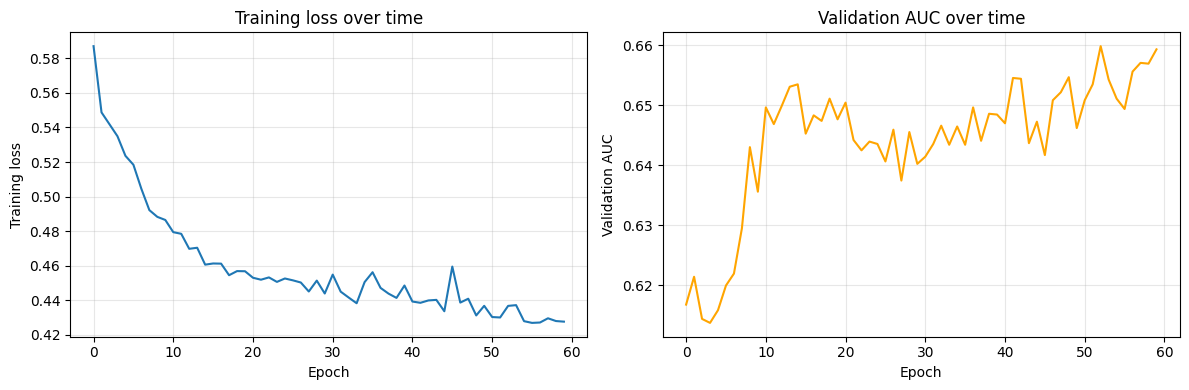

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training loss')
axes[0].set_title('Training loss over time')
axes[0].grid(alpha=0.3)

axes[1].plot(val_aucs, color='orange')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation AUC')
axes[1].set_title('Validation AUC over time')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curve.png', dpi=150)
plt.show()

## 6. Final test results: GCN vs. baseline

In [11]:
test_acc, test_auc = evaluate(test_loader)

print("=" * 50)
print("FINAL RESULTS (random split)")
print("=" * 50)
print(f"{'Model':<25}{'Accuracy':<12}{'AUC'}")
print(f"{'Silly baseline':<25}{baseline_acc:<12.3f}{baseline_auc:.3f}")
print(f"{'GCN (ours)':<25}{test_acc:<12.3f}{test_auc:.3f}")

FINAL RESULTS (random split)
Model                    Accuracy    AUC
Silly baseline           0.761       0.500
GCN (ours)               0.834       0.821


## 7. Save the model and results

(In Kaggle, also copy these files to `/kaggle/working/` or your connected Google Drive so a disconnect doesn't lose them.)

In [12]:
torch.save(model.state_dict(), 'gcn_bbbp_model.pt')

import json
results = {
    'baseline_accuracy': baseline_acc,
    'baseline_auc': baseline_auc,
    'gcn_accuracy': test_acc,
    'gcn_auc': test_auc,
}
with open('results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("Saved model to gcn_bbbp_model.pt and results to results.json")

Saved model to gcn_bbbp_model.pt and results to results.json


---
## Bonus (optional): a stronger network + the honest scaffold split

Two upgrades:
1. **GIN** (Graph Isomorphism Network) — generally a stronger message-passing architecture than plain GCN.
2. **Scaffold split** — instead of randomly splitting molecules, we split them by their core chemical "skeleton" (scaffold), so the test set contains structurally different molecules from the training set. This is harder and is the standard way molecule models are actually evaluated — watch the score drop compared to the random split above. That drop is expected and is the honest signal of how the model would do on genuinely new molecules.

In [13]:
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from collections import defaultdict
import random

def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)

def perform_stratified_scaffold_split(data_list, train_ratio=0.8, val_ratio=0.1):
    scaffolds_local = defaultdict(list)
    for i, d in enumerate(data_list):
        scaf = get_scaffold(d.smiles)
        if scaf is not None:
            scaffolds_local[scaf].append(i)

    # Sort scaffold groups by size (largest first)
    scaffold_groups_local = sorted(scaffolds_local.values(), key=len, reverse=True)

    n_local = len(data_list)
    train_cutoff_local = train_ratio * n_local
    val_cutoff_local = (train_ratio + val_ratio) * n_local

    train_indices_local, val_indices_local, test_indices_local = [], [], []

    # Greedily fill train/val/test
    for group in scaffold_groups_local:
        if len(train_indices_local) + len(group) <= train_cutoff_local:
            train_indices_local.extend(group)
        elif len(val_indices_local) + len(group) <= val_cutoff_local - train_cutoff_local:
            val_indices_local.extend(group)
        else:
            test_indices_local.extend(group)

    train_set_local = [data_list[i] for i in train_indices_local]
    val_set_local = [data_list[i] for i in val_indices_local]
    test_set_local = [data_list[i] for i in test_indices_local]

    random.shuffle(train_set_local)
    random.shuffle(val_set_local)
    random.shuffle(test_set_local)

    return train_set_local, val_set_local, test_set_local

# Separate molecules by class
class_0_molecules = [d for d in clean_list if d.y.item() == 0]
class_1_molecules = [d for d in clean_list if d.y.item() == 1]

# Perform scaffold split for each class independently
train_0, val_0, test_0 = perform_stratified_scaffold_split(class_0_molecules)
train_1, val_1, test_1 = perform_stratified_scaffold_split(class_1_molecules)

# Combine the splits and shuffle
scaffold_train = train_0 + train_1
scaffold_val = val_0 + val_1
scaffold_test = test_0 + test_1

random.shuffle(scaffold_train)
random.shuffle(scaffold_val)
random.shuffle(scaffold_test)

print(f"Scaffold split -> Train: {len(scaffold_train)} | Val: {len(scaffold_val)} | Test: {len(scaffold_test)}")

scaffold_train_loader = DataLoader(scaffold_train, batch_size=64, shuffle=True)
scaffold_val_loader = DataLoader(scaffold_val, batch_size=64, shuffle=False)
scaffold_test_loader = DataLoader(scaffold_test, batch_size=64, shuffle=False)

Scaffold split -> Train: 1631 | Val: 203 | Test: 205


In [14]:
from torch.nn import Sequential, ReLU

class GIN(torch.nn.Module):
    def __init__(self, num_node_features, hidden_channels=64):
        super().__init__()
        def mlp(in_dim, out_dim):
            return Sequential(Linear(in_dim, out_dim), ReLU(), Linear(out_dim, out_dim))

        self.conv1 = GINConv(mlp(num_node_features, hidden_channels))
        self.conv2 = GINConv(mlp(hidden_channels, hidden_channels))
        self.conv3 = GINConv(mlp(hidden_channels, hidden_channels))
        self.lin = Linear(hidden_channels, 1)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index).relu()
        x = self.conv3(x, edge_index)
        x = global_mean_pool(x, batch)
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.lin(x)
        return x

gin_model = GIN(dataset.num_node_features).to(device)
gin_optimizer = torch.optim.Adam(gin_model.parameters(), lr=0.001, weight_decay=5e-4)

def train_gin_epoch():
    gin_model.train()
    total_loss = 0
    for data in scaffold_train_loader:
        data = data.to(device)
        gin_optimizer.zero_grad()
        out = gin_model(data.x.float(), data.edge_index, data.batch) # Removed .squeeze()
        loss = criterion(out, data.y.float())
        loss.backward()
        gin_optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(scaffold_train_loader.dataset)

@torch.no_grad()
def evaluate_gin(loader):
    gin_model.eval()
    all_probs, all_labels = [], []
    for data in loader:
        data = data.to(device)
        out = gin_model(data.x.float(), data.edge_index, data.batch) # Removed .squeeze()
        probs = torch.sigmoid(out)
        all_probs.append(probs.cpu())
        all_labels.append(data.y.cpu())
    all_probs = torch.cat(all_probs).numpy()
    all_labels = torch.cat(all_labels).numpy()
    preds = (all_probs > 0.5).astype(int)
    return accuracy_score(all_labels, preds), roc_auc_score(all_labels, all_probs)

for epoch in range(1, 61):
    loss = train_gin_epoch()
    if epoch % 10 == 0:
        val_acc, val_auc = evaluate_gin(scaffold_val_loader)
        print(f"Epoch {epoch:03d} | Train loss: {loss:.4f} | Val acc: {val_acc:.3f} | Val AUC: {val_auc:.3f}")

Epoch 010 | Train loss: 0.5124 | Val acc: 0.768 | Val AUC: 0.877
Epoch 020 | Train loss: 0.5002 | Val acc: 0.872 | Val AUC: 0.899
Epoch 030 | Train loss: 0.4640 | Val acc: 0.862 | Val AUC: 0.902
Epoch 040 | Train loss: 0.4442 | Val acc: 0.931 | Val AUC: 0.907
Epoch 050 | Train loss: 0.4356 | Val acc: 0.916 | Val AUC: 0.909
Epoch 060 | Train loss: 0.4113 | Val acc: 0.936 | Val AUC: 0.902


In [15]:
# Check class distribution in scaffold_val_loader
val_labels = []
for data in scaffold_val_loader:
    val_labels.extend(data.y.cpu().numpy().flatten().tolist())

if len(set(val_labels)) < 2:
    print(f"Warning: Only one class found in scaffold_val_loader labels. ROC AUC cannot be calculated.\nFound labels: {set(val_labels)}")
else:
    class_counts = {cls: val_labels.count(cls) for cls in set(val_labels)}
    print(f"Class distribution in scaffold_val_loader: {class_counts}")

Class distribution in scaffold_val_loader: {0.0: 47, 1.0: 156}


In [16]:
gin_test_acc, gin_test_auc = evaluate_gin(scaffold_test_loader)

print("=" * 60)
print("COMPARISON: random split vs. honest scaffold split")
print("=" * 60)
print(f"{'Setup':<35}{'Accuracy':<12}{'AUC'}")
print(f"{'Baseline (random split)':<35}{baseline_acc:<12.3f}{baseline_auc:.3f}")
print(f"{'GCN (random split)':<35}{test_acc:<12.3f}{test_auc:.3f}")
print(f"{'GIN (scaffold split, harder)':<35}{gin_test_acc:<12.3f}{gin_test_auc:.3f}")
print("\nNotice the scaffold-split score is typically lower — that's expected and is")
print("the honest measure of how well the model generalizes to truly new molecules.")

COMPARISON: random split vs. honest scaffold split
Setup                              Accuracy    AUC
Baseline (random split)            0.761       0.500
GCN (random split)                 0.834       0.821
GIN (scaffold split, harder)       0.907       0.917

Notice the scaffold-split score is typically lower — that's expected and is
the honest measure of how well the model generalizes to truly new molecules.


---
## Understanding-checks

**Understanding-check 1: Why is a molecule a graph? What are the dots and the lines?**

A molecule is made of atoms connected by bonds. If you treat each **atom as a dot (node)** and each **bond as a line (edge)** connecting two atoms, the molecule's structure is exactly a graph. The node features carry information about the atom (e.g. element type, charge), and the graph's shape (which atoms connect to which) carries the chemical structure — which is what determines most of the molecule's properties.

**Understanding-check 2: What does "passing messages between atoms" mean?**

In each layer of the network, every atom looks at its directly bonded neighbor atoms and combines their information with its own (an average, sum, or learned combination) to produce an updated representation of itself. After several layers, each atom's representation has been shaped not just by itself but by atoms several bonds away — so the network ends up with a representation of the local chemical neighborhood around every atom, which is then pooled into a single representation of the whole molecule for prediction.

---
## What to hand in (checklist)

- [x] Notebook/code setup (this notebook, runs top to bottom)
- [x] The score (see results table above: GCN vs. baseline, and bonus GIN/scaffold comparison)
- [x] Short comparison table to the silly baseline (printed above)
- [x] Training graph (loss curve, plotted above)
- [x] Understanding-check answers (above)
- [ ] Push this notebook + a short README to GitHub
- [ ] Record a 2-3 minute screen demo walking through the results